In [21]:
import numpy as np 
import pandas as pd 

import scipy.stats as stats   # For QQ plot

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import FunctionTransformer   #New Topic(Learning Today)
from sklearn.compose import ColumnTransformer 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
df.sample(3)

,Survived,Age,Fare
439,0,31.000000,10.5000
42,0,29.699118,7.8958
95,0,29.699118,8.0500


In [9]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

GOAL : To see the data distribution (normal dist is preferable) 

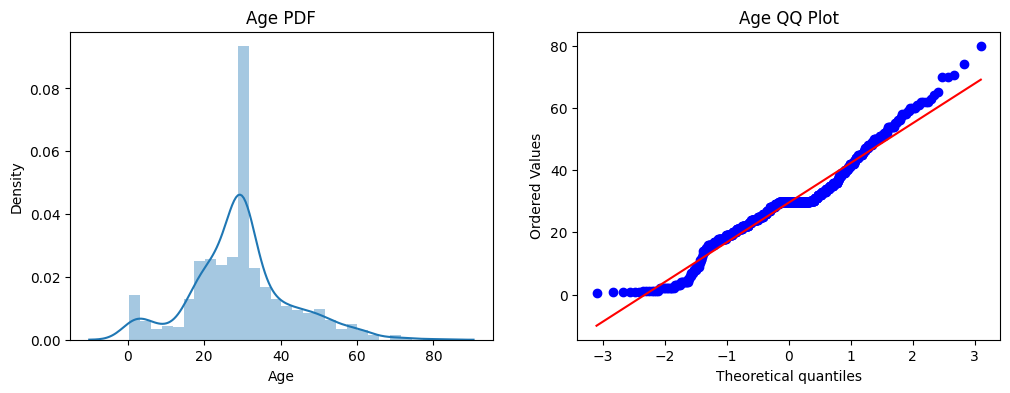

In [15]:
# Age 
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'],dist="norm",plot=plt)     #QQ plot
plt.title('Age QQ Plot')

plt.show  ; 

In [16]:
# Its closer to Normal Dist , thats good sign

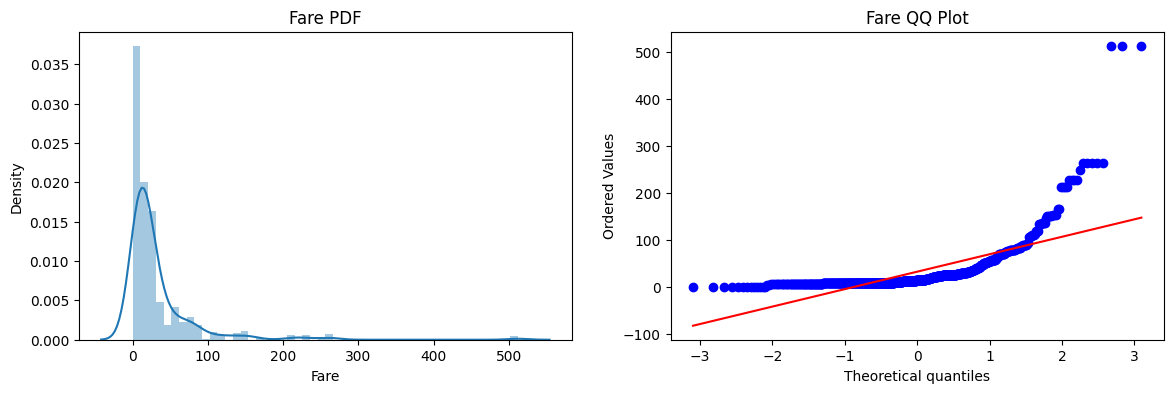

In [18]:
# Fare
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show() ; 

In [19]:
# Its a Right skewed data . Action -> to make Normal disct -> shift rightwards . 
# To shift the right skewed data -> We should use Log Transformation

#### Befor Applying Transformers 

In [22]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [23]:
clf.fit(x_train,y_train)      # put x train & y train, while trainig models 
clf2.fit(x_train,y_train)     # Fit = Learing model from data

y_pred = clf.predict(x_test)     # Predict , use only x test 
y_pred1 = clf2.predict(x_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


#### Applying Transformer 

In [24]:
trf = FunctionTransformer(func=np.log1p)

# Diff between np.log vs np.log1p 
# np.log : works on (x) , but it may create error is x = 0
# np.log1p : it uses (x+0.001) , so the x can't be 0 (No Errors)

In [25]:
# Performing steps all again to check the accuracy score
x_train_trans = trf.fit_transform(x_train)
x_test_trans = trf.transform(x_test)

In [30]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_trans,y_train)    # we are gonna use now x_train_trans(log trans data)
clf2.fit(x_train_trans,y_train)
    
y_pred = clf.predict(x_test_trans)
y_pred1 = clf2.predict(x_test_trans)
    
print("Accuracy LR after log transformer :",accuracy_score(y_test,y_pred))
print("Accuracy DT after log transformer :",accuracy_score(y_test,y_pred1))

Accuracy LR after log transformer : 0.6815642458100558
Accuracy DT after log transformer : 0.6871508379888268


In [35]:
# Doing Cross Val to See the Actual Changes

x_trans = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_trans,y,scoring='accuracy',cv=10)))   #cv = 10 means Model is gonna run 10 times 
print("DT",np.mean(cross_val_score(clf2,x_trans,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6543320848938826


In [36]:
# Results 

# Logistic Model have imporved from 65% -> 68%               (Good)
# Decision Tree does not show any diff 68% -> 65%            (Log transform does not affect Tree models)

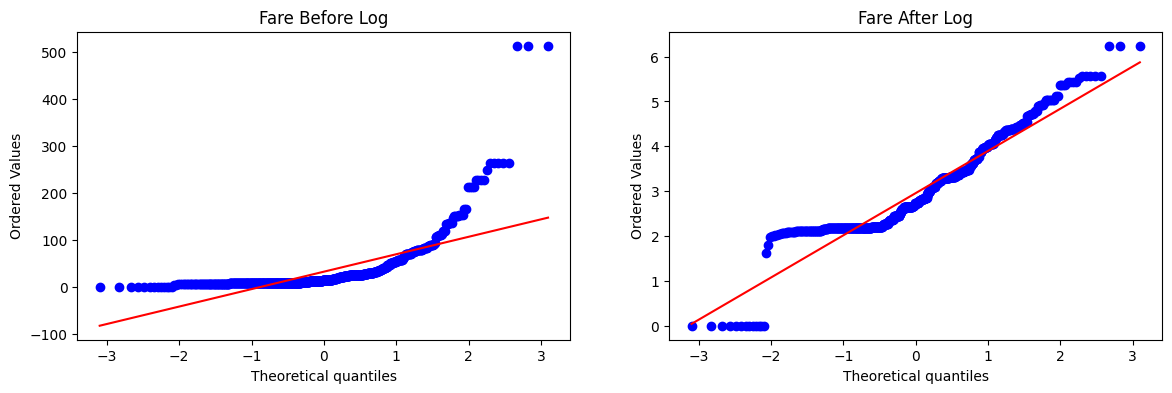

In [37]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_trans['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

In [39]:
# Better dist then before 

# QQ plot shows : If data is on the red line means the distribution is Normal Distribution

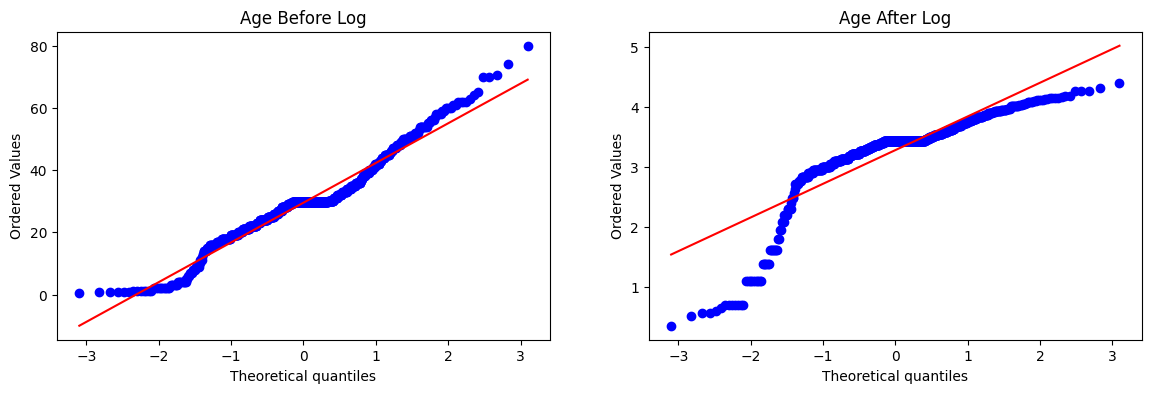

In [41]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_trans['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [42]:
# since the age disct was already somewhat near to Normal dist , by applying log transformation its gets worsen 
# Some dist gives inverse results like this also (we have to find when dist responeds best to your transformer)

In [43]:
# Since the Log transformer reacted bad to Age col , So we are applying Log transformer to the Fare col only

#### Applying Log trans to Fare col Only

In [54]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(x_train)
X_test_transformed2 = trf2.transform(x_test)

In [55]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849


In [57]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6555056179775282


#### Advance Function (just to see the changes)

In [58]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


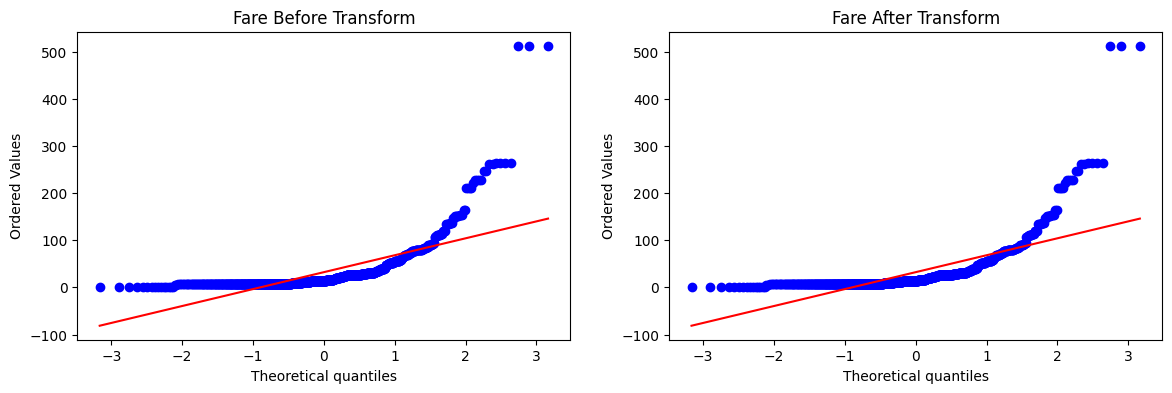

In [60]:
# x = none/basic
apply_transform(lambda x : x)

Accuracy 0.6431335830212235


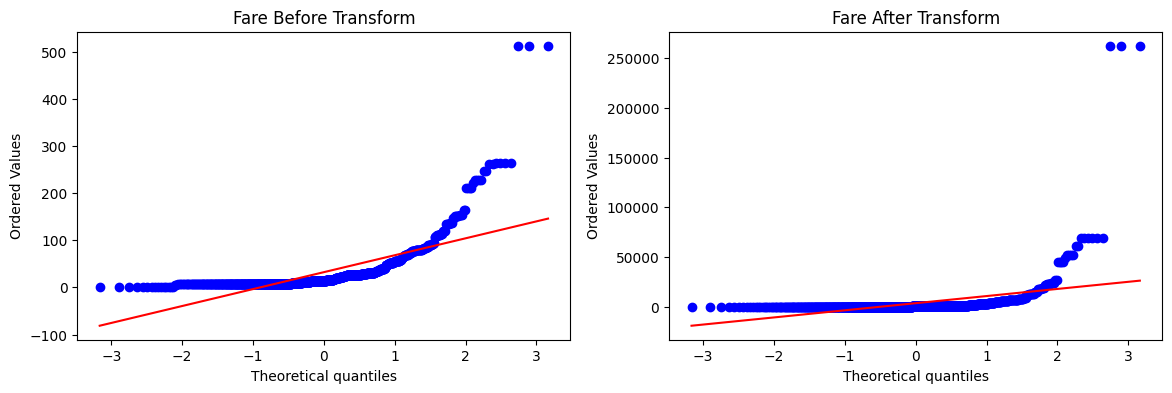

In [61]:
# Transformer : Square (x^2)
apply_transform(lambda x : x**2)

Accuracy 0.6262796504369538


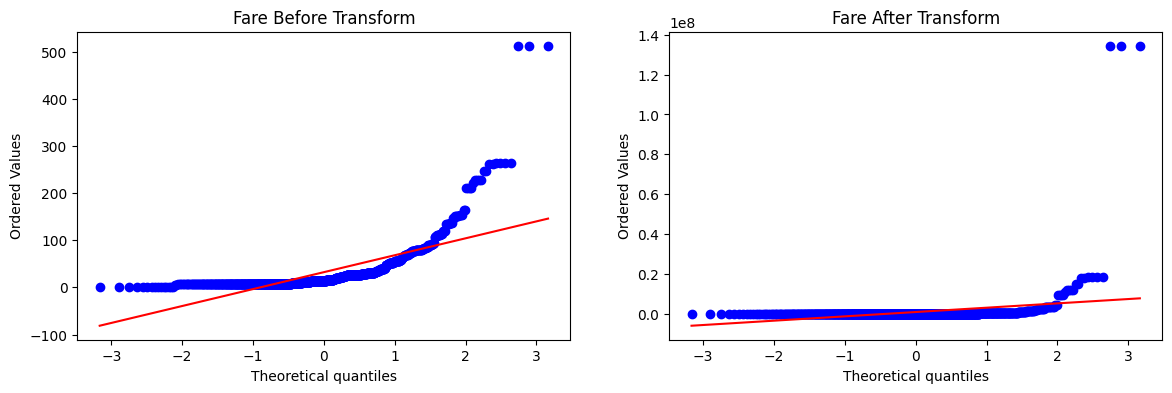

In [65]:
# Transformer : Cube (x^3)
apply_transform(lambda x : x**3)

Accuracy 0.6589013732833957


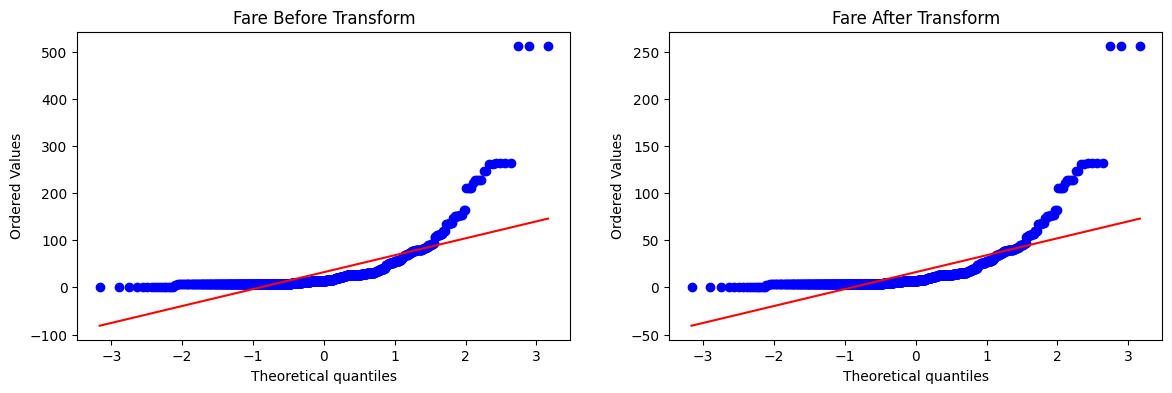

In [66]:
# Transformer : Square Root 
apply_transform(lambda x : x**1/2)

Accuracy 0.61729088639201


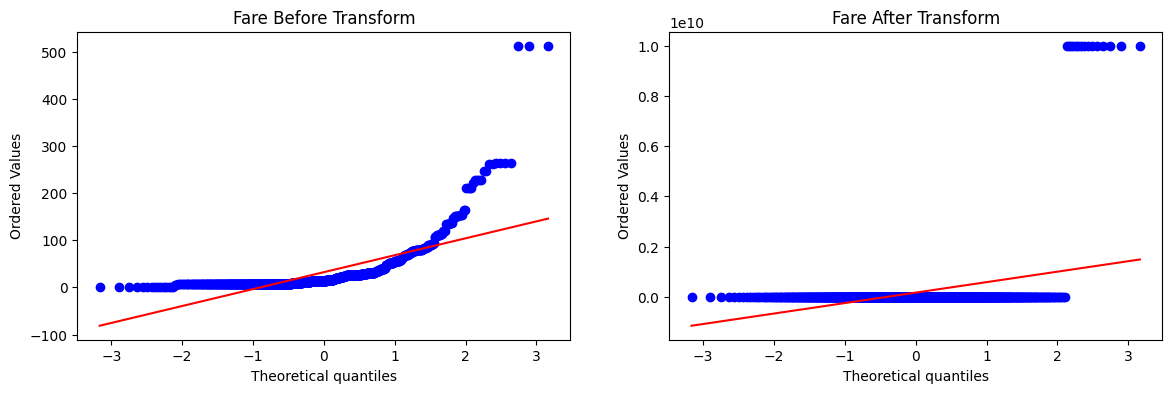

In [69]:
# Transformer : Log (inverse)
apply_transform(lambda x : 1/(x+0.0000000001))

Accuracy 0.6195131086142323


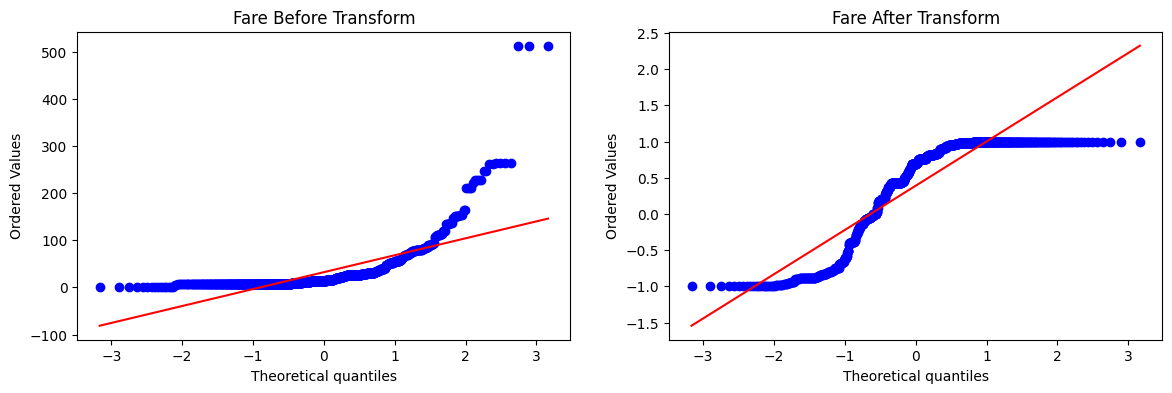

In [59]:
apply_transform(np.sin)